In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/jobs_raw.csv") 
df.head()


,job_id,job_title,company,location,posted_date,collected_date,years_experience_required,skills,source_website,job_url,work_model,notes
0,SWD001,Azure Developer,HiQ Finland,Helsinki,30/8/2026,30/9/2026,5,Azure;AWS;REST API;Git;SQL;DevOps;CI/CD;Java;P...,LinkedIn,https://www.linkedin.com/jobs/view/4446623744/,Hybrid,NaN
1,SWD002,IT Developer,GreenGold Group,Kuopio,9/9/2026,30/9/2026,2,PHP;Symfony;Git;Docker;Linux;Bash script;Nginx...,LinkedIn,https://www.linkedin.com/jobs/view/4463026176/,Hybrid,NaN
2,SWD003,Software Developer,Twoday,Helsinki,15/9/2026,30/9/2026,3,"C#; .NET;Vue;React;TypeScript;PostgreSQL, Mari...",LinkedIn,https://www.linkedin.com/jobs/view/4465549066/,Hybrid,NaN
3,SWD004,Software Developer,Wolt,Helsinki,15/9/2026,30/9/2026,Unknown,"Python;Go;AI tools;AWS;Kubernetes, Docker;Data...",LinkedIn,https://www.linkedin.com/jobs/view/4466174195/,On-site,NaN
4,SWD005,Software Developer,Elekta,Helsinki,25/9/2026,30/9/2026,3,REST API;C#;TypeScript;Angular;SQL;CI/CD,LinkedIn,https://www.linkedin.com/jobs/view/4471649152/,On-site,NaN


In [1]:
import os
os.getcwd()

'/Users/hoangtran/Documents/finnish-it-job-market-analysis/notebooks'

In [ ]:
df.info()

In [4]:
df["years_experience_required"].unique()

<StringArray>
['5', '2', '3', 'Unknown', 'Unkown', nan, '3-5']
Length: 7, dtype: str

In [6]:
df[df["years_experience_required"].isin(["Unknown","Unkown"])]

,job_id,job_title,company,location,posted_date,collected_date,years_experience_required,skills,source_website,job_url,work_model,notes
3,SWD004,Software Developer,Wolt,Helsinki,15/9/2026,30/9/2026,Unknown,"Python;Go;AI tools;AWS;Kubernetes, Docker;Data...",LinkedIn,https://www.linkedin.com/jobs/view/4466174195/,On-site,NaN
5,SWD006,Application Developer,Napa,Outokumpu,22/9/2026,30/9/2026,Unknown,AMK/University;English;Finnish;TypeScript;Java...,LinkedIn,https://www.linkedin.com/jobs/view/4468573827/,Hybrid,NaN
6,SWD007,Junior Fullstack - developer,Evolver,Helsinki,1/10/2026,1/10/2026,Unknown,Java; Kotlin;TypeScript;,LinkedIn,https://www.linkedin.com/jobs/view/4473786779/,Hybrid,NaN
7,SWD008,Backend Enginner,Star IT,Espoo,1/9/2026,1/10/2026,Unknown,C#;ASP.NET;EF Core;JWT;API;AI tools;xUnit;,LinkedIn,https://www.linkedin.com/jobs/view/4459957082/,On-site,NaN
9,SWD010,Applied AI Engineer,Euro-Biomaging,Turku,19/9/2026,1/10/2026,Unknown,UX/HCI;Python;FastAPI;Django;PostgreSQL;AI/LLM,LinkedIn,https://www.linkedin.com/jobs/view/4466083732/,Hybrid,NaN
10,SWD011,Senior Developer,Moder.app,Helsinki,27/9/2026,1/10/2026,Unknown,Vue/React;AI tools;UX;,LinkedIn,https://www.linkedin.com/jobs/view/4471444873/,Hybrid;Remote,Remote in Finland
11,DTA001,Data Analyst,Innofactor,Espoo,27/9/2026,1/10/2026,Unknown,Power BI; SQL;Microsoft Fabric;AI tools,LinkedIn,https://www.linkedin.com/jobs/view/4467370865/,Hybrid,NaN
13,DTA003,Senior Data Analyst,Greenstep,Turku,20/9/0206,1/10/2026,Unkown,DAX;M;SQL;Microsoft Fabric; Dataflows; Data Fa...,LinkedIn,https://www.linkedin.com/jobs/view/4463456129/,Hybrid,NaN
15,DTE001,Data Engineer,Saka,Oulu,27/9/2026,1/10/2026,Unknown,SQL;Python;CI/CD;GCP;AWS;Azure,LinkedIn,https://www.linkedin.com/jobs/view/4468531086/,Hybrid,NaN
16,DTE002,Data Engineer,Amesan Consulting Oy,Helsinki,27/9/2026,1/10/2026,Unknown,PostgreSQL;Python;SQL;ETL/ELT;AI tools,LinkedIn,https://www.linkedin.com/jobs/view/4468571901/,Hybrid,NaN


In [13]:
df[df["years_experience_required"].isna()]

,job_id,job_title,company,location,posted_date,collected_date,years_experience_required,skills,source_website,job_url,work_model,notes
14,DTA004,"Senior Specialist, Analytics & AI",Fazer,Vantaa,25/9/2026,1/10/2026,NaN,Power BI;AI tools;ML,LinkedIn,https://www.linkedin.com/jobs/view/4469380877/,Hybrid,NaN


In [14]:
df["years_experience_required"].value_counts()

years_experience_required
Unknown    9
3          4
5          3
2          2
Unkown     1
3-5        1
Name: count, dtype: int64

In [16]:
df["years_experience_required"].value_counts(dropna=False)

years_experience_required
Unknown    9
3          4
5          3
2          2
Unkown     1
NaN        1
3-5        1
Name: count, dtype: int64

In [23]:
df["years_experience_required"]=df["years_experience_required"].replace("Unkown","Unknown")

In [24]:
df["years_experience_required"].value_counts(dropna=False)

years_experience_required
Unknown    10
3           4
5           3
2           2
NaN         1
3-5         1
Name: count, dtype: int64

In [26]:
pd.to_numeric(
    df["years_experience_required"],
    errors="coerce")

0     5.0
1     2.0
2     3.0
3     NaN
4     3.0
5     NaN
6     NaN
7     NaN
8     3.0
9     NaN
10    NaN
11    NaN
12    2.0
13    NaN
14    NaN
15    NaN
16    NaN
17    5.0
18    3.0
19    5.0
20    NaN
Name: years_experience_required, dtype: float64

In [256]:
df["years_experience_min"] = df["years_experience_required"].str.extract(r"(\d+)")
df[["years_experience_required", "years_experience_min"]]

,years_experience_required,years_experience_min
0,5,5
1,2,2
2,3,3
3,Unknown,NaN
4,3,3
5,Unknown,NaN
6,Unknown,NaN
7,Unknown,NaN
8,3,3
9,Unknown,NaN


In [257]:
df["years_experience_min"].dtype

<StringDtype(storage='python', na_value=nan)>

In [258]:
df["years_experience_max"] = df["years_experience_max"].fillna(df["years_experience_min"])

In [259]:
df["years_experience_min"]= pd.to_numeric(df["years_experience_min"])
df["years_experience_min"].dtype

dtype('float64')

In [260]:
df["years_experience_max"] = df["years_experience_required"].str.extract(r"-(\d+)")


In [49]:
df["years_experience_max"] = pd.to_numeric(df["years_experience_max"])
df["years_experience_max"].dtype

dtype('float64')

In [50]:
df[["years_experience_required", "years_experience_min", "years_experience_max"]]

,years_experience_required,years_experience_min,years_experience_max
0,5,5.0,NaN
1,2,2.0,NaN
2,3,3.0,NaN
3,Unknown,NaN,NaN
4,3,3.0,NaN
5,Unknown,NaN,NaN
6,Unknown,NaN,NaN
7,Unknown,NaN,NaN
8,3,3.0,NaN
9,Unknown,NaN,NaN


In [52]:
df[["years_experience_required", "years_experience_min","years_experience_max"]]

,years_experience_required,years_experience_min,years_experience_max
0,5,5.0,5.0
1,2,2.0,2.0
2,3,3.0,3.0
3,Unknown,NaN,NaN
4,3,3.0,3.0
5,Unknown,NaN,NaN
6,Unknown,NaN,NaN
7,Unknown,NaN,NaN
8,3,3.0,3.0
9,Unknown,NaN,NaN


In [53]:
df[["years_experience_min", "years_experience_max"]].dtypes

years_experience_min    float64
years_experience_max    float64
dtype: object

In [57]:
df["posted_date"].unique()


<StringArray>
[ '30/8/2026',   '9/9/2026',  '15/9/2026',  '25/9/2026',  '22/9/2026',
  '1/10/2026',   '1/9/2026',  '23/9/2026',  '19/9/2026',  '27/9/2026',
 '28/09/2026',  '20/9/0206',  '13/9/2026',  '20/9/2026']
Length: 14, dtype: str

In [58]:
df["collected_date"].unique()

<StringArray>
['30/9/2026', '1/10/2026']
Length: 2, dtype: str

In [60]:
df["posted_date"] = pd.to_datetime(
    df["posted_date"],
    format="%d/%m/%Y"
)

In [61]:
df["posted_date"].unique()

<DatetimeArray>
['2026-08-30 00:00:00', '2026-09-09 00:00:00', '2026-09-15 00:00:00',
 '2026-09-25 00:00:00', '2026-09-22 00:00:00', '2026-10-01 00:00:00',
 '2026-09-01 00:00:00', '2026-09-23 00:00:00', '2026-09-19 00:00:00',
 '2026-09-27 00:00:00', '2026-09-28 00:00:00', '0206-09-20 00:00:00',
 '2026-09-13 00:00:00', '2026-09-20 00:00:00']
Length: 14, dtype: datetime64[us]

In [62]:
df[df["posted_date"].dt.year < 2000]

,job_id,job_title,company,location,posted_date,collected_date,years_experience_required,skills,source_website,job_url,work_model,notes,years_experience_min,years_experience_max
13,DTA003,Senior Data Analyst,Greenstep,Turku,206-09-20,1/10/2026,Unknown,DAX;M;SQL;Microsoft Fabric; Dataflows; Data Fa...,LinkedIn,https://www.linkedin.com/jobs/view/4463456129/,Hybrid,NaN,NaN,NaN


In [63]:
df.loc[df["job_id"]=="DTA003","posted_date"] = pd.Timestamp("2026-09-20")

In [65]:
df["posted_date"].unique()

<DatetimeArray>
['2026-08-30 00:00:00', '2026-09-09 00:00:00', '2026-09-15 00:00:00',
 '2026-09-25 00:00:00', '2026-09-22 00:00:00', '2026-10-01 00:00:00',
 '2026-09-01 00:00:00', '2026-09-23 00:00:00', '2026-09-19 00:00:00',
 '2026-09-27 00:00:00', '2026-09-28 00:00:00', '2026-09-20 00:00:00',
 '2026-09-13 00:00:00']
Length: 13, dtype: datetime64[us]

In [66]:
df[["posted_date", "collected_date"]].dtypes


posted_date       datetime64[us]
collected_date               str
dtype: object

In [68]:

df["collected_date"] = pd.to_datetime(
    df["collected_date"],
    format="%d/%m/%Y"
)

In [69]:
df["collected_date"].unique()

<DatetimeArray>
['2026-09-30 00:00:00', '2026-10-01 00:00:00']
Length: 2, dtype: datetime64[us]

In [70]:
df["days_since_posted"] = (
    df["collected_date"] - df["posted_date"]
)

In [71]:
df["days_since_posted"]

0    31 days
1    21 days
2    15 days
3    15 days
4     5 days
5     8 days
6     0 days
7    30 days
8     8 days
9    12 days
10    4 days
11    4 days
12    3 days
13   11 days
14    6 days
15    4 days
16    4 days
17   18 days
18    4 days
19   30 days
20   11 days
Name: days_since_posted, dtype: timedelta64[us]

In [72]:
df["days_since_posted"] = (df["collected_date"]-df["posted_date"])

In [73]:
df[["posted_date", "collected_date", "days_since_posted"]]

,posted_date,collected_date,days_since_posted
0,2026-08-30,2026-09-30,31 days
1,2026-09-09,2026-09-30,21 days
2,2026-09-15,2026-09-30,15 days
3,2026-09-15,2026-09-30,15 days
4,2026-09-25,2026-09-30,5 days
5,2026-09-22,2026-09-30,8 days
6,2026-10-01,2026-10-01,0 days
7,2026-09-01,2026-10-01,30 days
8,2026-09-23,2026-10-01,8 days
9,2026-09-19,2026-10-01,12 days


In [75]:
df["days_since_posted"]=df["days_since_posted"].dt.days

In [78]:
df["days_since_posted"].dtype

dtype('int64')

In [79]:
df["work_model"].value_counts(dropna=False)

work_model
Hybrid           17
On-site           3
Hybrid;Remote     1
Name: count, dtype: int64

In [80]:
df["work_model"].str.contains("Remote")

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10     True
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
Name: work_model, dtype: bool

In [81]:
df["is_remote"] = df["work_model"].str.contains("Remote")

In [82]:
df["is_remote"]

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10     True
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
Name: is_remote, dtype: bool

In [83]:
df["is_remote"].sum()

np.int64(1)

In [84]:
df[df["is_remote"]]

,job_id,job_title,company,location,posted_date,collected_date,years_experience_required,skills,source_website,job_url,work_model,notes,years_experience_min,years_experience_max,days_since_posted,is_remote
10,SWD011,Senior Developer,Moder.app,Helsinki,2026-09-27,2026-10-01,Unknown,Vue/React;AI tools;UX;,LinkedIn,https://www.linkedin.com/jobs/view/4471444873/,Hybrid;Remote,Remote in Finland,NaN,NaN,4,True


In [85]:
df["is_hybrid"] = df["work_model"].str.contains("Hybrid")

In [86]:
df["is_hybrid"]

0      True
1      True
2      True
3     False
4     False
5      True
6      True
7     False
8      True
9      True
10     True
11     True
12     True
13     True
14     True
15     True
16     True
17     True
18     True
19     True
20     True
Name: is_hybrid, dtype: bool

In [87]:
df["is_hybrid"].sum()

np.int64(18)

In [90]:
df["is_onsite"] = df["work_model"].str.contains("On-site")

In [91]:
df["is_onsite"].sum()

np.int64(3)

In [93]:
df[df["is_onsite"]]

,job_id,job_title,company,location,posted_date,collected_date,years_experience_required,skills,source_website,job_url,work_model,notes,years_experience_min,years_experience_max,days_since_posted,is_remote,is_hybrid,is_onsite
3,SWD004,Software Developer,Wolt,Helsinki,2026-09-15,2026-09-30,Unknown,"Python;Go;AI tools;AWS;Kubernetes, Docker;Data...",LinkedIn,https://www.linkedin.com/jobs/view/4466174195/,On-site,NaN,NaN,NaN,15,False,False,True
4,SWD005,Software Developer,Elekta,Helsinki,2026-09-25,2026-09-30,3,REST API;C#;TypeScript;Angular;SQL;CI/CD,LinkedIn,https://www.linkedin.com/jobs/view/4471649152/,On-site,NaN,3.0,3.0,5,False,False,True
7,SWD008,Backend Enginner,Star IT,Espoo,2026-09-01,2026-10-01,Unknown,C#;ASP.NET;EF Core;JWT;API;AI tools;xUnit;,LinkedIn,https://www.linkedin.com/jobs/view/4459957082/,On-site,NaN,NaN,NaN,30,False,False,True


In [96]:
round(df["is_remote"].sum()/len(df)*100,2)

np.float64(4.76)

In [97]:
df["job_id"].str[:3]

0     SWD
1     SWD
2     SWD
3     SWD
4     SWD
5     SWD
6     SWD
7     SWD
8     SWD
9     SWD
10    SWD
11    DTA
12    DTA
13    DTA
14    DTA
15    DTE
16    DTE
17    DTE
18    AIE
19    AIE
20    AIE
Name: job_id, dtype: str

In [102]:
df["job_id"].str[:3].value_counts()

job_id
SWD    11
DTA     4
DTE     3
AIE     3
Name: count, dtype: int64

In [104]:
round(df["job_id"].str[:3].value_counts(normalize=True)*100,2)

job_id
SWD    52.38
DTA    19.05
DTE    14.29
AIE    14.29
Name: proportion, dtype: float64

In [105]:
df["skills"].head()

0    Azure;AWS;REST API;Git;SQL;DevOps;CI/CD;Java;P...
1    PHP;Symfony;Git;Docker;Linux;Bash script;Nginx...
2    C#; .NET;Vue;React;TypeScript;PostgreSQL, Mari...
3    Python;Go;AI tools;AWS;Kubernetes, Docker;Data...
4             REST API;C#;TypeScript;Angular;SQL;CI/CD
Name: skills, dtype: str

In [107]:
df["skills"].iloc[0].split(";")

['Azure', 'AWS', 'REST API', 'Git', 'SQL', 'DevOps', 'CI/CD', 'Java', 'Python']

In [108]:
df["skills"].str.split(";")

0     [Azure, AWS, REST API, Git, SQL, DevOps, CI/CD...
1     [PHP, Symfony, Git, Docker, Linux, Bash script...
2     [C#,  .NET, Vue, React, TypeScript, PostgreSQL...
3     [Python, Go, AI tools, AWS, Kubernetes, Docker...
4       [REST API, C#, TypeScript, Angular, SQL, CI/CD]
5     [AMK/University, English, Finnish, TypeScript,...
6                         [Java,  Kotlin, TypeScript, ]
7     [C#, ASP.NET, EF Core, JWT, API, AI tools, xUn...
8     [AI tools, C#/NET, REST APIs, CI/CD, React, An...
9     [UX/HCI, Python, FastAPI, Django, PostgreSQL, ...
10                          [Vue/React, AI tools, UX, ]
11         [Power BI,  SQL, Microsoft Fabric, AI tools]
12                                   [Power BI, API/AI]
13    [DAX, M, SQL, Microsoft Fabric,  Dataflows,  D...
14                             [Power BI, AI tools, ML]
15                [SQL, Python, CI/CD, GCP, AWS, Azure]
16         [PostgreSQL, Python, SQL, ETL/ELT, AI tools]
17                             [ETL/ELT, SQL, Py

In [109]:
df["skills"].str.split(";").iloc[6]


['Java', ' Kotlin', 'TypeScript', '']

In [111]:
skills = [x.strip()for x in df["skills"].str.split(";").iloc[6]]
skills = [x for x in skills if x]
skills

['Java', 'Kotlin', 'TypeScript']

In [114]:
skills = [x.strip() for x in df["skills"].str.split(";").iloc[6]]
skills = [x for x in skills if x]
skills

['Java', 'Kotlin', 'TypeScript']

In [120]:
df["skills_list"] = df["skills"].str.split(";")

In [121]:
df["skills_list"].head()

0    [Azure, AWS, REST API, Git, SQL, DevOps, CI/CD...
1    [PHP, Symfony, Git, Docker, Linux, Bash script...
2    [C#,  .NET, Vue, React, TypeScript, PostgreSQL...
3    [Python, Go, AI tools, AWS, Kubernetes, Docker...
4      [REST API, C#, TypeScript, Angular, SQL, CI/CD]
Name: skills_list, dtype: object

In [122]:
df["skills_list"].apply(len).head()

0     9
1    10
2     9
3     7
4     6
Name: skills_list, dtype: int64

In [124]:
def clean_skills(skills):
    return [x.strip()for x in skills if x.strip()]

df["skills_list"] = df["skills_list"].apply(clean_skills)

In [126]:
df["skill_list"]

0     [Azure, AWS, REST API, Git, SQL, DevOps, CI/CD...
1     [PHP, Symfony, Git, Docker, Linux, Bash script...
2     [C#, .NET, Vue, React, TypeScript, PostgreSQL,...
3     [Python, Go, AI tools, AWS, Kubernetes, Docker...
4       [REST API, C#, TypeScript, Angular, SQL, CI/CD]
5     [AMK/University, English, Finnish, TypeScript,...
6                            [Java, Kotlin, TypeScript]
7     [C#, ASP.NET, EF Core, JWT, API, AI tools, xUnit]
8     [AI tools, C#/NET, REST APIs, CI/CD, React, An...
9     [UX/HCI, Python, FastAPI, Django, PostgreSQL, ...
10                            [Vue/React, AI tools, UX]
11          [Power BI, SQL, Microsoft Fabric, AI tools]
12                                   [Power BI, API/AI]
13    [DAX, M, SQL, Microsoft Fabric, Dataflows, Dat...
14                             [Power BI, AI tools, ML]
15                [SQL, Python, CI/CD, GCP, AWS, Azure]
16         [PostgreSQL, Python, SQL, ETL/ELT, AI tools]
17                               [ETL/ELT, SQL, 

In [127]:
df= df.drop(columns ="skill_list")

In [128]:
df.columns

Index(['job_id', 'job_title', 'company', 'location', 'posted_date',
       'collected_date', 'years_experience_required', 'skills',
       'source_website', 'job_url', 'work_model', 'notes',
       'years_experience_min', 'years_experience_max', 'days_since_posted',
       'is_remote', 'is_hybrid', 'is_onsite', 'skills_list'],
      dtype='str')

In [129]:
df["skills_list"] = df["skills_list"].apply(clean_skills)

In [130]:
df["skills_list"].head()

0    [Azure, AWS, REST API, Git, SQL, DevOps, CI/CD...
1    [PHP, Symfony, Git, Docker, Linux, Bash script...
2    [C#, .NET, Vue, React, TypeScript, PostgreSQL,...
3    [Python, Go, AI tools, AWS, Kubernetes, Docker...
4      [REST API, C#, TypeScript, Angular, SQL, CI/CD]
Name: skills_list, dtype: object

In [132]:
df["skills_list"].apply(lambda x: "" in x).sum()

np.int64(0)

In [134]:
df["skills_list"].explode().head(15)


0          Azure
0            AWS
0       REST API
0            Git
0            SQL
0         DevOps
0          CI/CD
0           Java
0         Python
1            PHP
1        Symfony
1            Git
1         Docker
1          Linux
1    Bash script
Name: skills_list, dtype: str

In [135]:
df["skills_list"].explode().value_counts().head(10)

skills_list
SQL           9
Python        9
AI tools      7
CI/CD         5
TypeScript    5
AWS           4
Java          4
Azure         3
Git           3
PostgreSQL    3
Name: count, dtype: int64

In [ ]:
df["skills"].explode().value_counts()

skills
Azure;AWS;REST API;Git;SQL;DevOps;CI/CD;Java;Python                             1
PHP;Symfony;Git;Docker;Linux;Bash script;Nginx;SSH;MySQL;PostgreSQL             1
C#; .NET;Vue;React;TypeScript;PostgreSQL, MariaDB; Azure/AWS;English;Finnish    1
Python;Go;AI tools;AWS;Kubernetes, Docker;DataDog;SQL, NoSQL                    1
REST API;C#;TypeScript;Angular;SQL;CI/CD                                        1
AMK/University;English;Finnish;TypeScript;Java;Python;C/C++;Git;SQL;MySQL       1
Java; Kotlin;TypeScript;                                                        1
C#;ASP.NET;EF Core;JWT;API;AI tools;xUnit;                                      1
AI tools;C#/NET;REST APIs;CI/CD;React;Angular;TypeScript                        1
UX/HCI;Python;FastAPI;Django;PostgreSQL;AI/LLM                                  1
Vue/React;AI tools;UX;                                                          1
Power BI; SQL;Microsoft Fabric;AI tools                                         1
Power BI;

In [137]:
df["skills_list"].explode().value_counts()

skills_list
SQL           9
Python        9
AI tools      7
CI/CD         5
TypeScript    5
             ..
JS            1
AI/ML         1
LLMs          1
AIOps         1
APIs          1
Name: count, Length: 70, dtype: int64

In [138]:
df["skills_list"].explode().value_counts().head(10)

skills_list
SQL           9
Python        9
AI tools      7
CI/CD         5
TypeScript    5
AWS           4
Java          4
Azure         3
Git           3
PostgreSQL    3
Name: count, dtype: int64

In [139]:
top_skills = df["skills_list"].explode().value_counts().head(10)

In [140]:
top_skills

skills_list
SQL           9
Python        9
AI tools      7
CI/CD         5
TypeScript    5
AWS           4
Java          4
Azure         3
Git           3
PostgreSQL    3
Name: count, dtype: int64

SQL and Python were each required in 42.86% of the 21 job postings in this sample, followed by AI tools at 33.33%.

In [142]:
round(top_skills/len(df)*100,2)

skills_list
SQL           42.86
Python        42.86
AI tools      33.33
CI/CD         23.81
TypeScript    23.81
AWS           19.05
Java          19.05
Azure         14.29
Git           14.29
PostgreSQL    14.29
Name: count, dtype: float64

In [143]:
df["job_id"].str[:3] == "DTA"

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11     True
12     True
13     True
14     True
15    False
16    False
17    False
18    False
19    False
20    False
Name: job_id, dtype: bool

In [144]:
dta_jobs = df[df["job_id"].str[:3]== "DTA"]

In [145]:
dta_jobs [["job_id","job_title","skills_list"]]


,job_id,job_title,skills_list
11,DTA001,Data Analyst,"[Power BI, SQL, Microsoft Fabric, AI tools]"
12,DTA002,AI&Data Specialist,"[Power BI, API/AI]"
13,DTA003,Senior Data Analyst,"[DAX, M, SQL, Microsoft Fabric, Dataflows, Dat..."
14,DTA004,"Senior Specialist, Analytics & AI","[Power BI, AI tools, ML]"


In [147]:
dta_jobs["skills_list"].explode().value_counts()

skills_list
Power BI            3
SQL                 2
Microsoft Fabric    2
AI tools            2
API/AI              1
DAX                 1
M                   1
Dataflows           1
Data Factory        1
ML                  1
Name: count, dtype: int64

In [148]:
dta_skills = dta_jobs["skills_list"].explode().value_counts()

In [149]:
dta_skills/len(dta_jobs)*100

skills_list
Power BI            75.0
SQL                 50.0
Microsoft Fabric    50.0
AI tools            50.0
API/AI              25.0
DAX                 25.0
M                   25.0
Dataflows           25.0
Data Factory        25.0
ML                  25.0
Name: count, dtype: float64

DTE


In [153]:
dte_jobs = df[df["job_id"].str[:3]== "DTE"]

In [154]:
dte_jobs [["job_id","job_title","skills_list"]]

,job_id,job_title,skills_list
15,DTE001,Data Engineer,"[SQL, Python, CI/CD, GCP, AWS, Azure]"
16,DTE002,Data Engineer,"[PostgreSQL, Python, SQL, ETL/ELT, AI tools]"
17,DTE003,Data Engineer,"[ETL/ELT, SQL, Python]"


In [155]:
dte_jobs["skills_list"].explode().value_counts()

skills_list
SQL           3
Python        3
ETL/ELT       2
CI/CD         1
GCP           1
AWS           1
Azure         1
PostgreSQL    1
AI tools      1
Name: count, dtype: int64

In [156]:
dte_skills = dte_jobs["skills_list"].explode().value_counts()

In [158]:
round(dte_skills/len(dte_jobs)*100,2)

skills_list
SQL           100.00
Python        100.00
ETL/ELT        66.67
CI/CD          33.33
GCP            33.33
AWS            33.33
Azure          33.33
PostgreSQL     33.33
AI tools       33.33
Name: count, dtype: float64

AIE


In [164]:
aie_jobs = df[df["job_id"].str[:3]=="AIE"]

In [165]:
aie_jobs[["job_id","job_title","skills_list"]]

,job_id,job_title,skills_list
18,AIE001,AI Engineer,"[Azure, AWS, MLOps, Gen AI, Python, Java, MCP ..."
19,AIE002,AI Sofware Developer,"[Node.js, React, HTML, CSS, JS, API]"
20,AIE003,AI Engineer,"[AI/ML, Gen AI, LLMs, CI/CD, Python, AIOps, AP..."


In [166]:
aie_jobs["skills_list"].explode().value_counts()

skills_list
Gen AI              2
Python              2
Azure               1
AWS                 1
MLOps               1
Java                1
MCP integrations    1
Node.js             1
React               1
HTML                1
CSS                 1
JS                  1
API                 1
AI/ML               1
LLMs                1
CI/CD               1
AIOps               1
APIs                1
SQL                 1
Name: count, dtype: int64

SWD


In [169]:
swd_jobs = df[df["job_id"].str[:3]=="SWD"]

In [170]:
swd_jobs[["job_id","job_title","skills_list"]]

,job_id,job_title,skills_list
0,SWD001,Azure Developer,"[Azure, AWS, REST API, Git, SQL, DevOps, CI/CD..."
1,SWD002,IT Developer,"[PHP, Symfony, Git, Docker, Linux, Bash script..."
2,SWD003,Software Developer,"[C#, .NET, Vue, React, TypeScript, PostgreSQL,..."
3,SWD004,Software Developer,"[Python, Go, AI tools, AWS, Kubernetes, Docker..."
4,SWD005,Software Developer,"[REST API, C#, TypeScript, Angular, SQL, CI/CD]"
5,SWD006,Application Developer,"[AMK/University, English, Finnish, TypeScript,..."
6,SWD007,Junior Fullstack - developer,"[Java, Kotlin, TypeScript]"
7,SWD008,Backend Enginner,"[C#, ASP.NET, EF Core, JWT, API, AI tools, xUnit]"
8,SWD009,Software Engineer,"[AI tools, C#/NET, REST APIs, CI/CD, React, An..."
9,SWD010,Applied AI Engineer,"[UX/HCI, Python, FastAPI, Django, PostgreSQL, ..."


In [171]:
swd_jobs["skills_list"].explode().value_counts()

skills_list
TypeScript             5
Python                 4
AI tools               4
Git                    3
SQL                    3
CI/CD                  3
Java                   3
C#                     3
AWS                    2
REST API               2
MySQL                  2
PostgreSQL             2
React                  2
English                2
Finnish                2
Angular                2
Azure                  1
DevOps                 1
PHP                    1
Symfony                1
Docker                 1
Linux                  1
Bash script            1
Nginx                  1
SSH                    1
.NET                   1
Vue                    1
PostgreSQL, MariaDB    1
Azure/AWS              1
Go                     1
Kubernetes, Docker     1
DataDog                1
SQL, NoSQL             1
AMK/University         1
C/C++                  1
Kotlin                 1
ASP.NET                1
EF Core                1
JWT                    1
API          

Create job category

In [172]:
df["job_category"] = df["job_id"].str[:3]

In [173]:
df[["job_id","job_category"]].head()

,job_id,job_category
0,SWD001,SWD
1,SWD002,SWD
2,SWD003,SWD
3,SWD004,SWD
4,SWD005,SWD


In [174]:
df["job_category"].value_counts()

job_category
SWD    11
DTA     4
DTE     3
AIE     3
Name: count, dtype: int64

In [176]:
skill_category = df[["job_category","skills_list"]].explode("skills_list")

In [178]:
skill_category.head(10)

,job_category,skills_list
0,SWD,Azure
0,SWD,AWS
0,SWD,REST API
0,SWD,Git
0,SWD,SQL
0,SWD,DevOps
0,SWD,CI/CD
0,SWD,Java
0,SWD,Python
1,SWD,PHP


GROUP JOB BY CATEGORY

In [179]:
skill_category.groupby("job_category")["skills_list"].value_counts()

job_category  skills_list        
AIE           Gen AI                 2
              Python                 2
              SQL                    1
              Azure                  1
              AWS                    1
                                    ..
SWD           Go                     1
              Azure/AWS              1
              PostgreSQL, MariaDB    1
              SQL, NoSQL             1
              UX/HCI                 1
Name: count, Length: 87, dtype: int64

In [182]:
skill_counts = (
    skill_category
    .groupby("job_category")["skills_list"]
    .value_counts
)

In [185]:
type(skill_counts)

method

In [186]:
skill_count_by_category = (
    skill_category
    .groupby("job_category")["skills_list"]
    .value_counts()
)

In [187]:
type(skill_count_by_category)

pandas.Series

In [189]:
skill_count_by_category.head(10)

job_category  skills_list     
AIE           Gen AI              2
              Python              2
              SQL                 1
              Azure               1
              AWS                 1
              MLOps               1
              Java                1
              MCP integrations    1
              Node.js             1
              APIs                1
Name: count, dtype: int64

In [193]:
skill_count_df = skill_count_by_category.reset_index()

In [194]:
skill_count_df.head(10)

,job_category,skills_list,count
0,AIE,Gen AI,2
1,AIE,Python,2
2,AIE,SQL,1
3,AIE,Azure,1
4,AIE,AWS,1
5,AIE,MLOps,1
6,AIE,Java,1
7,AIE,MCP integrations,1
8,AIE,Node.js,1
9,AIE,APIs,1


In [196]:
skill_count_df = skill_count_df.rename(
    columns={
        "skills_list": "skill",
        "count": "job_count"
    }
)

In [197]:
skill_count_df.head(10)

,job_category,skill,job_count
0,AIE,Gen AI,2
1,AIE,Python,2
2,AIE,SQL,1
3,AIE,Azure,1
4,AIE,AWS,1
5,AIE,MLOps,1
6,AIE,Java,1
7,AIE,MCP integrations,1
8,AIE,Node.js,1
9,AIE,APIs,1


In [198]:
category_counts = df["job_category"].value_counts()

In [199]:
category_counts

job_category
SWD    11
DTA     4
DTE     3
AIE     3
Name: count, dtype: int64

In [200]:
skill_count_df["job_category"].map(category_counts)

0      3
1      3
2      3
3      3
4      3
      ..
82    11
83    11
84    11
85    11
86    11
Name: job_category, Length: 87, dtype: int64

In [201]:
skill_count_df["category_job_count"] = skill_count_df["job_category"].map(category_counts)

In [202]:
skill_count_df.head(10)

,job_category,skill,job_count,category_job_count
0,AIE,Gen AI,2,3
1,AIE,Python,2,3
2,AIE,SQL,1,3
3,AIE,Azure,1,3
4,AIE,AWS,1,3
5,AIE,MLOps,1,3
6,AIE,Java,1,3
7,AIE,MCP integrations,1,3
8,AIE,Node.js,1,3
9,AIE,APIs,1,3


In [205]:
skill_count_df["job_percentage"] = (
    round(skill_count_df["job_count"]
    / skill_count_df["category_job_count"]
    * 100,2)
)

In [206]:
skill_count_df.head()

,job_category,skill,job_count,category_job_count,job_percentage
0,AIE,Gen AI,2,3,66.67
1,AIE,Python,2,3,66.67
2,AIE,SQL,1,3,33.33
3,AIE,Azure,1,3,33.33
4,AIE,AWS,1,3,33.33


In [207]:
top5_skills = (
    skill_count_df
    .sort_values(["job_category", "job_count"], ascending=[True, False])
    .groupby("job_category")
    .head(5)
)

In [208]:
top5_skills

,job_category,skill,job_count,category_job_count,job_percentage
0,AIE,Gen AI,2,3,66.67
1,AIE,Python,2,3,66.67
2,AIE,SQL,1,3,33.33
3,AIE,Azure,1,3,33.33
4,AIE,AWS,1,3,33.33
19,DTA,Power BI,3,4,75.00
20,DTA,SQL,2,4,50.00
21,DTA,AI tools,2,4,50.00
22,DTA,Microsoft Fabric,2,4,50.00
23,DTA,Dataflows,1,4,25.00


In [209]:
dta_top5 = top5_skills[top5_skills["job_category"]== "DTA"]

In [210]:
dta_top5

,job_category,skill,job_count,category_job_count,job_percentage
19,DTA,Power BI,3,4,75.0
20,DTA,SQL,2,4,50.0
21,DTA,AI tools,2,4,50.0
22,DTA,Microsoft Fabric,2,4,50.0
23,DTA,Dataflows,1,4,25.0


BAR CHART BASIC


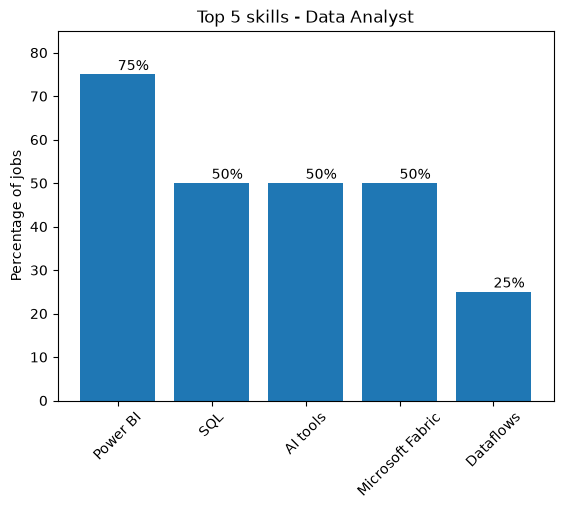

In [221]:
import matplotlib.pyplot as plt
plt.bar(dta_top5["skill"],dta_top5["job_percentage"])
plt.title("Top 5 skills - Data Analyst")
plt.xticks(rotation=45)
plt.ylim(0,85)
for i, value in enumerate(dta_top5["job_percentage"]):
    plt.text(i,value+1,f"{value:.0f}%")
plt.ylabel("Percentage of jobs")
plt.show()

In [222]:
top5_skills["job_category"].value_counts()

job_category
AIE    5
DTA    5
DTE    5
SWD    5
Name: count, dtype: int64

AIE chart bar


In [223]:
aie_top5 = top5_skills[top5_skills["job_category"]=="AIE"]

In [224]:
aie_top5

,job_category,skill,job_count,category_job_count,job_percentage
0,AIE,Gen AI,2,3,66.67
1,AIE,Python,2,3,66.67
2,AIE,SQL,1,3,33.33
3,AIE,Azure,1,3,33.33
4,AIE,AWS,1,3,33.33


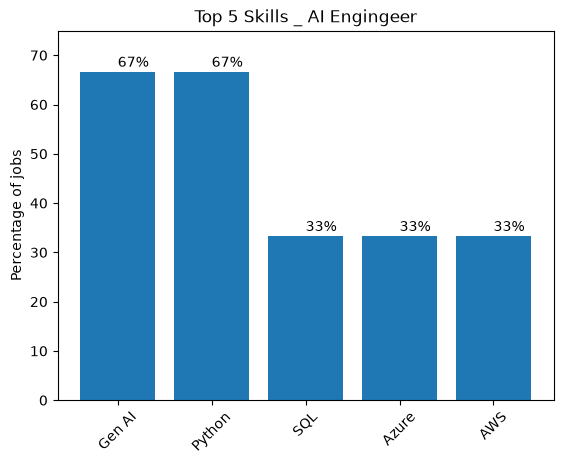

In [227]:
plt.bar(aie_top5["skill"],aie_top5["job_percentage"])
plt.title("Top 5 Skills _ AI Engingeer")
plt.ylabel("Percentage of jobs")
plt.xticks(rotation = 45)
plt.ylim(0,75)
for i,value in enumerate(aie_top5["job_percentage"]):
    plt.text(i,value + 1,f"{value:.0f}%")
plt.show()

In [228]:
top5_skills["job_category"].unique()


<StringArray>
['AIE', 'DTA', 'DTE', 'SWD']
Length: 4, dtype: str

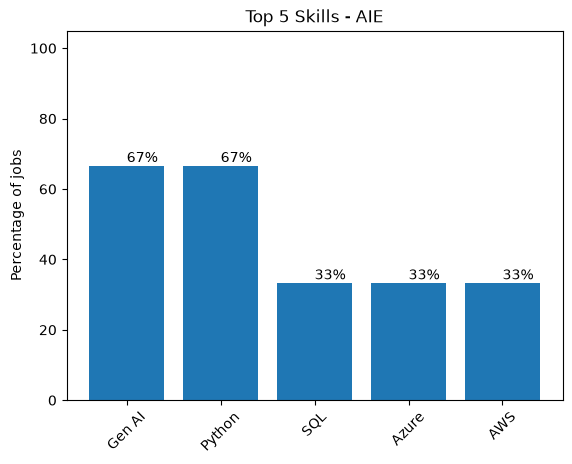

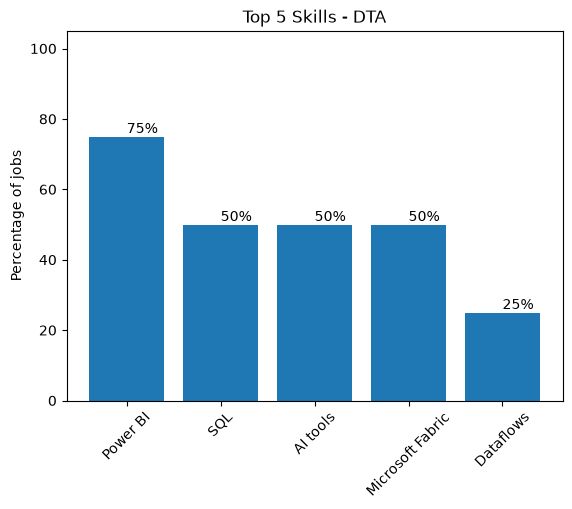

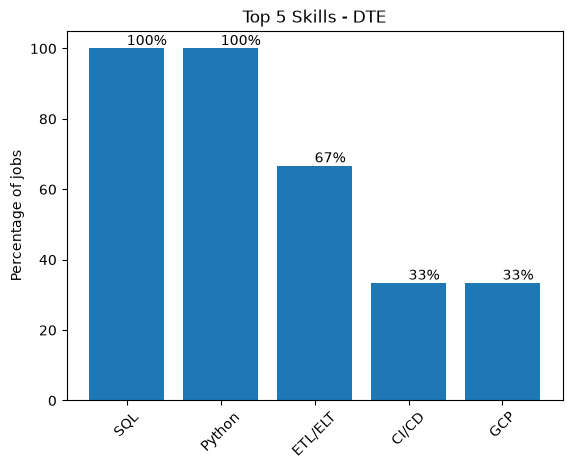

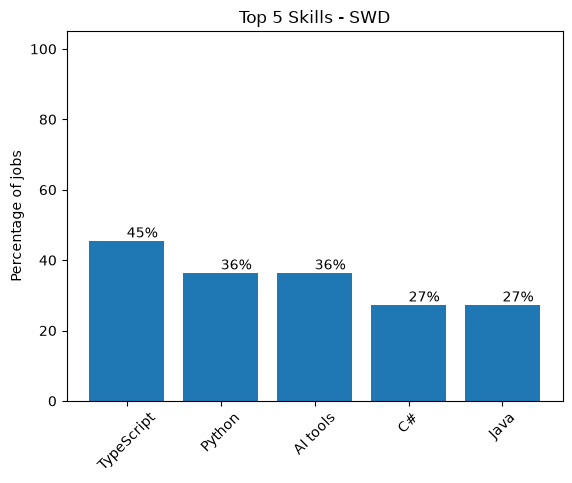

In [232]:
for category in top5_skills["job_category"].unique():
    category_data = top5_skills[top5_skills["job_category"]==category]
    plt.bar(category_data["skill"],category_data["job_percentage"])
    plt.title(f"Top 5 Skills - {category}")
    plt.ylabel("Percentage of jobs")
    plt.xticks(rotation=45)
    plt.ylim(0,105)
    for i, value in enumerate(category_data["job_percentage"]):
        plt.text(i,value+1,f"{value:.0f}%")
    plt.show()

Which skills appear overlap analysis? 

In [234]:
skill_category.groupby("skills_list")["job_category"].nunique()

skills_list
.NET         1
AI tools     3
AI/LLM       1
AI/ML        1
AIOps        1
            ..
UX           1
UX/HCI       1
Vue          1
Vue/React    1
xUnit        1
Name: job_category, Length: 70, dtype: int64

Which skills appear in more than one job category? 

In [235]:
skill_category.groupby("skills_list")["job_category"].nunique()

skills_list
.NET         1
AI tools     3
AI/LLM       1
AI/ML        1
AIOps        1
            ..
UX           1
UX/HCI       1
Vue          1
Vue/React    1
xUnit        1
Name: job_category, Length: 70, dtype: int64

In [236]:
skill_category.groupby("skills_list")["job_category"].nunique().sort_values(ascending=False).head(10)

skills_list
SQL           4
CI/CD         3
AWS           3
AI tools      3
Python        3
Azure         3
PostgreSQL    2
React         2
Java          2
API           2
Name: job_category, dtype: int64

In [237]:
skill_category.groupby("skills_list")["job_category"].unique()

skills_list
.NET                   [SWD]
AI tools     [SWD, DTA, DTE]
AI/LLM                 [SWD]
AI/ML                  [AIE]
AIOps                  [AIE]
                  ...       
UX                     [SWD]
UX/HCI                 [SWD]
Vue                    [SWD]
Vue/React              [SWD]
xUnit                  [SWD]
Name: job_category, Length: 70, dtype: object

In [238]:
skill_category.groupby("skills_list")["job_category"].agg(
    ["nunique", "unique"]
).sort_values("nunique", ascending=False).head(10)

,nunique,unique
skills_list,,
SQL,4,"[SWD, DTA, DTE, AIE]"
CI/CD,3,"[SWD, DTE, AIE]"
AWS,3,"[SWD, DTE, AIE]"
AI tools,3,"[SWD, DTA, DTE]"
Python,3,"[SWD, DTE, AIE]"
Azure,3,"[SWD, DTE, AIE]"
PostgreSQL,2,"[SWD, DTE]"
React,2,"[SWD, AIE]"
Java,2,"[SWD, AIE]"


In [239]:
dta_skills = skill_count_df[
    skill_count_df["job_category"] == "DTA"
]

In [240]:
dta_skills.sort_values("job_count", ascending=False)

,job_category,skill,job_count,category_job_count,job_percentage
19,DTA,Power BI,3,4,75.0
20,DTA,SQL,2,4,50.0
21,DTA,AI tools,2,4,50.0
22,DTA,Microsoft Fabric,2,4,50.0
23,DTA,Dataflows,1,4,25.0
24,DTA,M,1,4,25.0
25,DTA,DAX,1,4,25.0
26,DTA,ML,1,4,25.0
27,DTA,API/AI,1,4,25.0
28,DTA,Data Factory,1,4,25.0


In [241]:
skill_category.groupby("skills_list")["job_category"].nunique()

skills_list
.NET         1
AI tools     3
AI/LLM       1
AI/ML        1
AIOps        1
            ..
UX           1
UX/HCI       1
Vue          1
Vue/React    1
xUnit        1
Name: job_category, Length: 70, dtype: int64

In [243]:
skill_category.groupby("skills_list")["job_category"].nunique().loc[
    lambda x: x == 1
]

skills_list
.NET                   1
AI/LLM                 1
AI/ML                  1
AIOps                  1
AMK/University         1
API/AI                 1
APIs                   1
ASP.NET                1
Angular                1
Azure/AWS              1
Bash script            1
C#                     1
C#/NET                 1
C/C++                  1
CSS                    1
DAX                    1
Data Factory           1
DataDog                1
Dataflows              1
DevOps                 1
Django                 1
Docker                 1
EF Core                1
ETL/ELT                1
English                1
FastAPI                1
Finnish                1
GCP                    1
Gen AI                 1
Git                    1
Go                     1
HTML                   1
JS                     1
JWT                    1
Kotlin                 1
Kubernetes, Docker     1
LLMs                   1
Linux                  1
M                      1
MCP integrati

In [244]:
skill_category.groupby("skills_list")["job_category"].unique()

skills_list
.NET                   [SWD]
AI tools     [SWD, DTA, DTE]
AI/LLM                 [SWD]
AI/ML                  [AIE]
AIOps                  [AIE]
                  ...       
UX                     [SWD]
UX/HCI                 [SWD]
Vue                    [SWD]
Vue/React              [SWD]
xUnit                  [SWD]
Name: job_category, Length: 70, dtype: object

In [246]:
skill_category.groupby("skills_list")["job_category"].unique().loc[
    lambda x: x.str.len() == 1
]

skills_list
.NET                   [SWD]
AI/LLM                 [SWD]
AI/ML                  [AIE]
AIOps                  [AIE]
AMK/University         [SWD]
API/AI                 [DTA]
APIs                   [AIE]
ASP.NET                [SWD]
Angular                [SWD]
Azure/AWS              [SWD]
Bash script            [SWD]
C#                     [SWD]
C#/NET                 [SWD]
C/C++                  [SWD]
CSS                    [AIE]
DAX                    [DTA]
Data Factory           [DTA]
DataDog                [SWD]
Dataflows              [DTA]
DevOps                 [SWD]
Django                 [SWD]
Docker                 [SWD]
EF Core                [SWD]
ETL/ELT                [DTE]
English                [SWD]
FastAPI                [SWD]
Finnish                [SWD]
GCP                    [DTE]
Gen AI                 [AIE]
Git                    [SWD]
Go                     [SWD]
HTML                   [AIE]
JS                     [AIE]
JWT                    [SWD]
Ko

In [247]:
specialized_skills = (
    skill_category
    .groupby("skills_list")["job_category"]
    .unique()
)

specialized_skills = specialized_skills[
    specialized_skills.str.len() == 1
]

specialized_skills.apply(lambda x: x[0]).value_counts()

job_category
SWD    39
AIE    11
DTA     8
DTE     2
Name: count, dtype: int64

In our sample of 21 postings, AI Engineer roles showed a relatively diverse set of category-specific skills, although the small sample size limits generalization.

In [248]:
dta_skills[["skill", "job_percentage"]]

,skill,job_percentage
19,Power BI,75.0
20,SQL,50.0
21,AI tools,50.0
22,Microsoft Fabric,50.0
23,Dataflows,25.0
24,M,25.0
25,DAX,25.0
26,ML,25.0
27,API/AI,25.0
28,Data Factory,25.0


In [249]:
dta_skills.sort_values("job_percentage", ascending=False)[
    ["skill", "job_percentage"]
]

,skill,job_percentage
19,Power BI,75.0
20,SQL,50.0
21,AI tools,50.0
22,Microsoft Fabric,50.0
23,Dataflows,25.0
24,M,25.0
25,DAX,25.0
26,ML,25.0
27,API/AI,25.0
28,Data Factory,25.0


In [250]:
dta_skills["priority"] = "Low"

In [251]:
dta_skills.loc[dta_skills["job_percentage"] >= 50, "priority"] = "High"

In [252]:
dta_skills.loc[dta_skills["job_percentage"] >= 50, "priority"] = "High"

In [254]:
dta_skills.loc[
    (dta_skills["job_percentage"] >= 25) &
    (dta_skills["job_percentage"] < 50),
    "priority"
] = "Medium"

In [255]:
dta_skills[["skill", "job_percentage", "priority"]]

,skill,job_percentage,priority
19,Power BI,75.0,High
20,SQL,50.0,High
21,AI tools,50.0,High
22,Microsoft Fabric,50.0,High
23,Dataflows,25.0,Medium
24,M,25.0,Medium
25,DAX,25.0,Medium
26,ML,25.0,Medium
27,API/AI,25.0,Medium
28,Data Factory,25.0,Medium


In [261]:
df.columns

Index(['job_id', 'job_title', 'company', 'location', 'posted_date',
       'collected_date', 'years_experience_required', 'skills',
       'source_website', 'job_url', 'work_model', 'notes',
       'years_experience_min', 'years_experience_max', 'days_since_posted',
       'is_remote', 'is_hybrid', 'is_onsite', 'skills_list', 'job_category'],
      dtype='str')

In [262]:
df.to_csv("../data/processed/jobs_cleaned.csv", index=False)